In [1]:
#%%time
import os
import re
import gzip
import math
import random
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt

from ast import literal_eval
import warnings
# 忽略 FutureWarning 类型警告
warnings.simplefilter(action='ignore', category=FutureWarning)
# 忽略特定类型的警告：忽略 scanpy包中含有 ignore 的 UserWarning 类型警告
warnings.filterwarnings("ignore", category=UserWarning, module="scanpy")
# 禁用 pandas 包中的 SettingWithCopyWarning 类型警告  
pd.options.mode.chained_assignment = None  # 或 'raise' 表示引发异常

import inferECC
from inferECC import *

species value: hg38
species == 'mm10':  False


In [2]:
from matplotlib_venn import venn2
import upsetplot

In [3]:
### anno ecdna2gene oncogene pathway
### import ecdna2gene2pathway function

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

# Function to generate 10 random colors
def generate_random_colors(num_colors=10):
    return [np.random.rand(3,) for _ in range(num_colors)]
# Generate random colors
random_colors = generate_random_colors(10)

# Define a Morandi-style color palette (soft, muted, pastel-like colors)
morandi_colors = [
    '#D8BFD8',  # Thistle
    '#B4A6A4',  # Light grayish brown
    '#A89F91',  # Grayish olive green
    '#C9ADA1',  # Soft pinkish beige
    '#D0B0A1',  # Light brownish pink
    '#B4A8A1',  # Light mauve
    '#C4A1C1',  # Soft lavender
    '#D7C2A1',  # Light beige
    '#E0C9B9',  # Light warm gray
    '#BFB8B1'   # Soft beige
]
# Define a bright and high-contrast Morandi-inspired color palette
bright_morandi_colors = [
  '#F8C8D3',  # Soft pink
  '#F7E3A1',  # Light pastel yellow
  '#C2D8A3',  # Light green
  '#F1B7C1',  # Soft peach
  '#A8D6E1',  # Light blue
  '#D1B0D2',  # Soft lavender
  '#E0C8A0',  # Light beige
  '#D8E5C8',  # Pale mint green
  '#F1E2A5',  # Light pastel orange
  '#E9A4C3'   # Light pinkish mauve
]

In [6]:
def get_all_folders(path):
    folders = [f for f in os.listdir(path) if os.path.isdir(os.path.join(path, f))]
    return folders
"""
# 指定路径
target_path = library_dir # '/your/target/directory'
# 获取所有文件夹
folders_list = get_all_folders(target_path)
"""

"\n# 指定路径\ntarget_path = library_dir # '/your/target/directory'\n# 获取所有文件夹\nfolders_list = get_all_folders(target_path)\n"

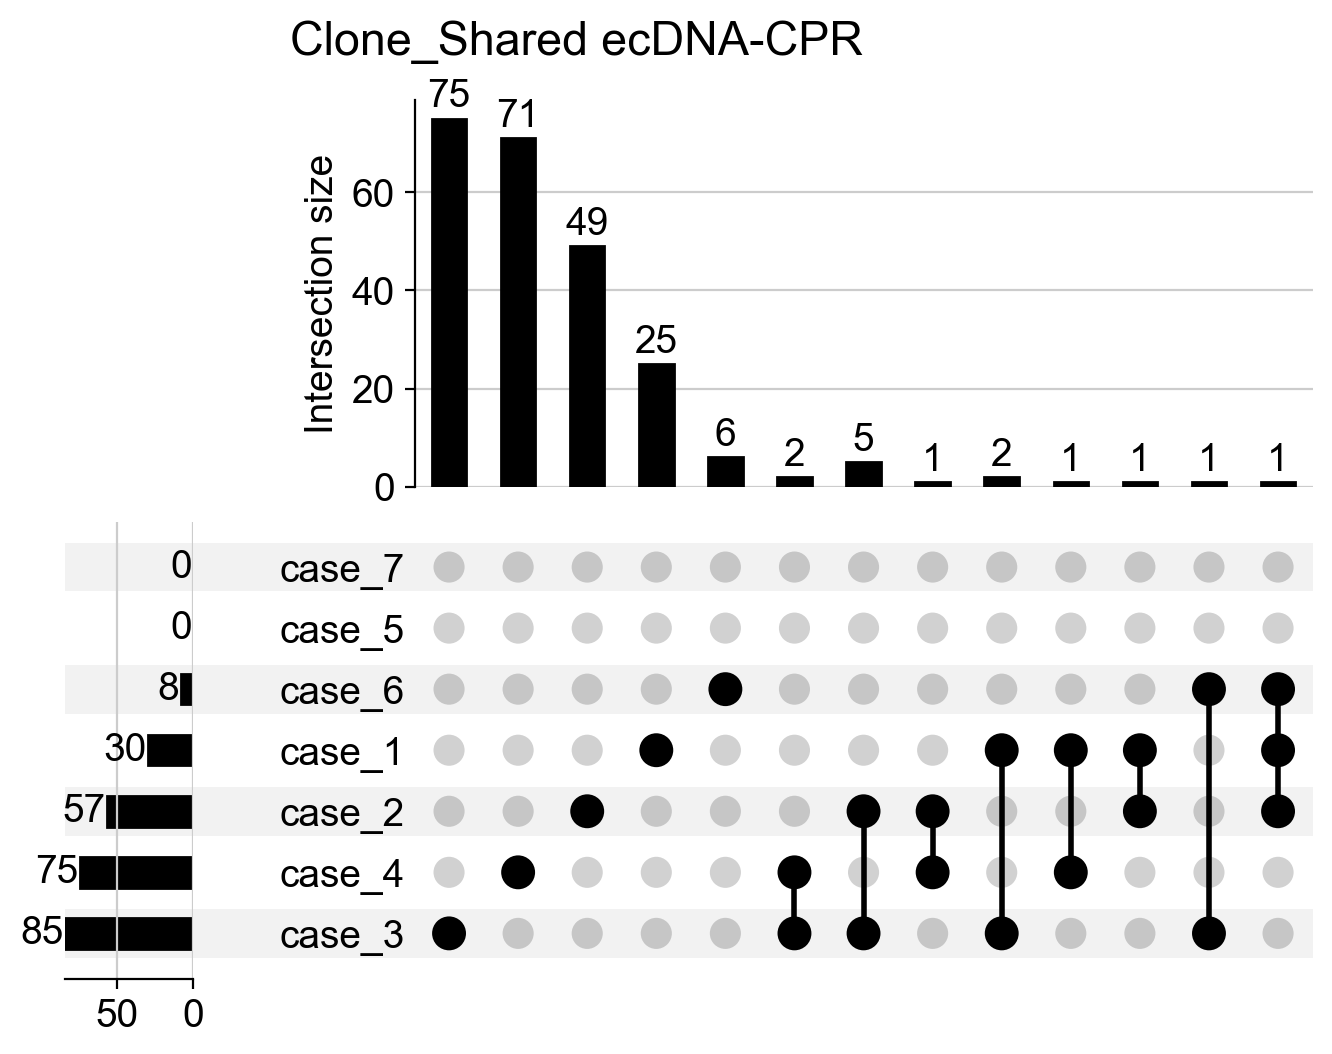

In [23]:
increased_list = list()
for i in range(7):
    primary_path = f"D:/02.project/18.ecDNA/02.code/v0.1.1/fig_cpr_rbg_stat_2/07.tracing/02.cluster_nx/s{i}"
    #tb_temp = pd.read_table(primary_path+f"/f27-ecDNA_change-seu.markers.xls", index_col=0)
    tb_temp = pd.read_table(primary_path+f"/f25-02-df_ecdna_gene_oncogene.xls", index_col=0)
    list_temp = tb_temp[(tb_temp["ecDNA_change"]=="Shared_ecDNA")]["gene"].to_list()
    increased_list.append(list_temp)
    
# 将列表转换为适合UpSetPlot的数据格式
contents = {f'case_{i+1}': set(lst) for i, lst in enumerate(increased_list)}
upset_data = upsetplot.from_contents(contents)
# 绘制UpSet图
upset = upsetplot.UpSet(upset_data, show_counts=True)
upset.plot()
plt.suptitle(f'Clone_Shared ecDNA-CPR')
plt.savefig(f'./fig_cpr_rbg_stat_2/07.tracing/02.cluster_nx/shared_common/f01-Clone_Shared.pdf', bbox_inches='tight')
# 显示图形
plt.show()

In [24]:
df_reset = upset_data.reset_index()
# 将前 7 列的值从 True/False 转换为 1/0
df_reset.iloc[:, :7] = df_reset.iloc[:, :7].astype(int)
# 计算前 7 列的和，并将结果作为新的一列添加到 DataFrame
df_reset['sum'] = df_reset.iloc[:, :7].sum(axis=1)
df_reset.to_csv(f'./fig_cpr_rbg_stat_2/07.tracing/02.cluster_nx/shared_common/f01-Clone_Shared.xls', sep='\t', index=True)
df_reset

,case_1,case_2,case_3,case_4,case_5,case_6,case_7,id,sum
0,1,0,0,0,0,0,0,chr6:31700000_31800000,1
1,1,0,0,0,0,0,0,chr19:39400000_39500000,1
2,1,0,0,0,0,0,0,chr12:6300000_6400000,1
3,1,0,0,0,0,0,0,chr17:75000000_75100000,1
4,1,0,0,0,0,0,0,chr12:56600000_56700000,1
...,...,...,...,...,...,...,...,...,...
235,0,0,0,0,0,1,0,chr19:4400000_4500000,1
236,0,0,0,0,0,1,0,chr6:31600000_31700000,1
237,0,0,0,0,0,1,0,chr11:67600000_67700000,1
238,0,0,0,0,0,1,0,chr2:219500000_219600000,1


In [25]:
df_reset_subset = df_reset[df_reset["sum"] >= 2]
df_reset_subset.to_csv(f'./fig_cpr_rbg_stat_2/07.tracing/02.cluster_nx/shared_common/f02-Clone_Shared-common.xls', sep='\t', index=True)
df_reset_subset

,case_1,case_2,case_3,case_4,case_5,case_6,case_7,id,sum
6,1,0,1,0,0,0,0,chr12:6800000_6900000,2
18,1,1,0,0,0,1,0,chr19:2100000_2200000,3
20,1,0,1,0,0,0,0,chr19:42400000_42500000,2
22,1,0,0,1,0,0,0,chr19:40200000_40300000,2
24,1,1,0,0,0,0,0,chr20:63500000_63600000,2
41,0,1,1,0,0,0,0,chr17:4900000_5000000,2
59,0,1,0,1,0,0,0,chr22:43100000_43200000,2
69,0,1,1,0,0,0,0,chr1:32700000_32800000,2
76,0,1,1,0,0,0,0,chr22:37700000_37800000,2
78,0,1,1,0,0,0,0,chr20:31500000_31600000,2


In [26]:
len(df_reset_subset)

14

In [27]:
df_cpr = df_reset_subset
df_cpr["chr_raw"] = df_cpr["id"]

In [28]:
### anno ecdna2gene oncogene pathway

In [29]:
df_ecdna = df_cpr.copy()
df_ecdna_gene = genebody_region(df_fragments=df_ecdna,species="hg38")
df_ecdna_gene['oncogene'] = df_ecdna_gene['genebody_region_gene'].apply(custom_transform)
df_ecdna_gene.to_csv(f'./fig_cpr_rbg_stat_2/07.tracing/02.cluster_nx/shared_common/f03-common_cpr_gene_oncogene.xls', sep='\t', index=True)
df_ecdna_gene

species value: hg38


,case_1,case_2,case_3,case_4,case_5,case_6,case_7,id,sum,chr_raw,genebody_region,genebody_region_gene,oncogene
6,1,0,1,0,0,0,0,chr12:6800000_6900000,2,chr12:6800000_6900000,12,"[CD4, GPR162, P3H3, GNB3, CDCA3, USP5, TPI1, S...",[]
18,1,1,0,0,0,1,0,chr19:2100000_2200000,3,chr19:2100000_2200000,2,"[AP3D1, DOT1L]",[]
20,1,0,1,0,0,0,0,chr19:42400000_42500000,2,chr19:42400000_42500000,6,"[LIPE-AS1, LIPE, CTB-50E14.4, CXCL17, RNU4-60P...",[]
22,1,0,0,1,0,0,0,chr19:40200000_40300000,2,chr19:40200000_40300000,7,"[MAP3K10, TTC9B, CNTD2, AKT2, CTC-425O23.2, MI...",[AKT2]
24,1,1,0,0,0,0,0,chr20:63500000_63600000,2,chr20:63500000_63600000,8,"[RP4-697K14.3, PPDPF, PTK6, SRMS, RP4-697K14.1...",[PTK6]
41,0,1,1,0,0,0,0,chr17:4900000_5000000,2,chr17:4900000_5000000,17,"[CHRNE, C17orf107, GP1BA, SLC25A11, RNF167, PF...",[]
59,0,1,0,1,0,0,0,chr22:43100000_43200000,2,chr22:43100000_43200000,5,"[BIK, MCAT, TSPO, TTLL12, SCUBE1]",[]
69,0,1,1,0,0,0,0,chr1:32700000_32800000,2,chr1:32700000_32800000,4,"[SYNC, RP11-114B7.6, KIAA1522, YARS]",[]
76,0,1,1,0,0,0,0,chr22:37700000_37800000,2,chr22:37700000_37800000,2,"[RP1-37E16.12, TRIOBP]",[]
78,0,1,1,0,0,0,0,chr20:31500000_31600000,2,chr20:31500000_31600000,7,"[HM13, RP3-324O17.7, MCTS2P, HM13-IT1, HM13-AS...",[]


In [30]:
df_ecdna_gene["group"] = "Increased_common" 
df_merge_onco = group_merge(df_ecdna_gene,"group","oncogene")
# 计算col1列每个元素的长度，并创建新的col2列
df_merge_onco['oncogene_nor_number'] = df_merge_onco['oncogene_nor'].apply(lambda x: len(x))
df_merge_onco.to_csv(f'./fig_cpr_rbg_stat_2/07.tracing/02.cluster_nx/increased_common/f03-common_cpr_gene_oncogene-df_merge_onco.xls', 
                     sep='\t', index=True)
df_merge_onco

,group,oncogene_nor,most_oncogene_nor,oncogene_nor_number
0,Increased_common,"[SH3GL1, CNBP, ASPSCR1, GNA11, SETD1B]","[SH3GL1, CNBP, ASPSCR1, GNA11, SETD1B]",5


In [31]:
df_merge_body = group_merge(df_ecdna_gene,"group","genebody_region_gene")
# 计算col1列每个元素的长度，并创建新的col2列
df_merge_body['genebody_region_gene_nor_number'] = df_merge_body['genebody_region_gene_nor'].apply(lambda x: len(x))
df_merge_body.to_csv(f'./fig_cpr_rbg_stat_2/07.tracing/02.cluster_nx/increased_common/f03-common_cpr_gene_oncogene-df_merge_body.xls', 
                     sep='\t', index=True)
df_merge_body

,group,genebody_region_gene_nor,most_genebody_region_gene_nor,genebody_region_gene_nor_number
0,Increased_common,"[RP11-326C3.4, IFITM2, RP11-326C3.7, IFITM1, R...","[RP11-326C3.4, IFITM2, RP11-326C3.7, IFITM1, R...",194


In [32]:
### pathway

In [33]:
df_merge_onco = df_merge_onco[df_merge_onco['oncogene_nor_number'] != 0]
df_merge_onco

,group,oncogene_nor,most_oncogene_nor,oncogene_nor_number
0,Increased_common,"[SH3GL1, CNBP, ASPSCR1, GNA11, SETD1B]","[SH3GL1, CNBP, ASPSCR1, GNA11, SETD1B]",5


In [34]:
gsea_path = os.getcwd()+'./fig_cpr_rbg_stat_2/07.tracing/02.cluster_nx/increased_common/oncogene-pathway/'
if not os.path.exists(gsea_path): os.makedirs(gsea_path, exist_ok=True)
enrich_list = []
for sample in df_merge_onco["group"].unique():
    print(sample)
    gene_list = df_merge_onco[df_merge_onco["group"]==sample]["oncogene_nor"].to_list()[0]
    enr_res_temp = gp_enrichr(gene_list=gene_list,sample=sample,path=gsea_path)
    print("done.")
    enrich_list.append(enr_res_temp)
    pass

Increased_common
done.


In [35]:
enr_res_onco = pd.concat(enrich_list)
enr_res_onco["cluster"] = pd.Categorical(enr_res_onco["cluster"],
                                      categories=list(enr_res_onco["cluster"].unique())[::-1],
                                      ordered=True)
enr_res_onco.to_csv('./fig_cpr_rbg_stat_2/07.tracing/02.cluster_nx/increased_common/f04-onco-gene-pathway.xls', sep='\t', index=True)

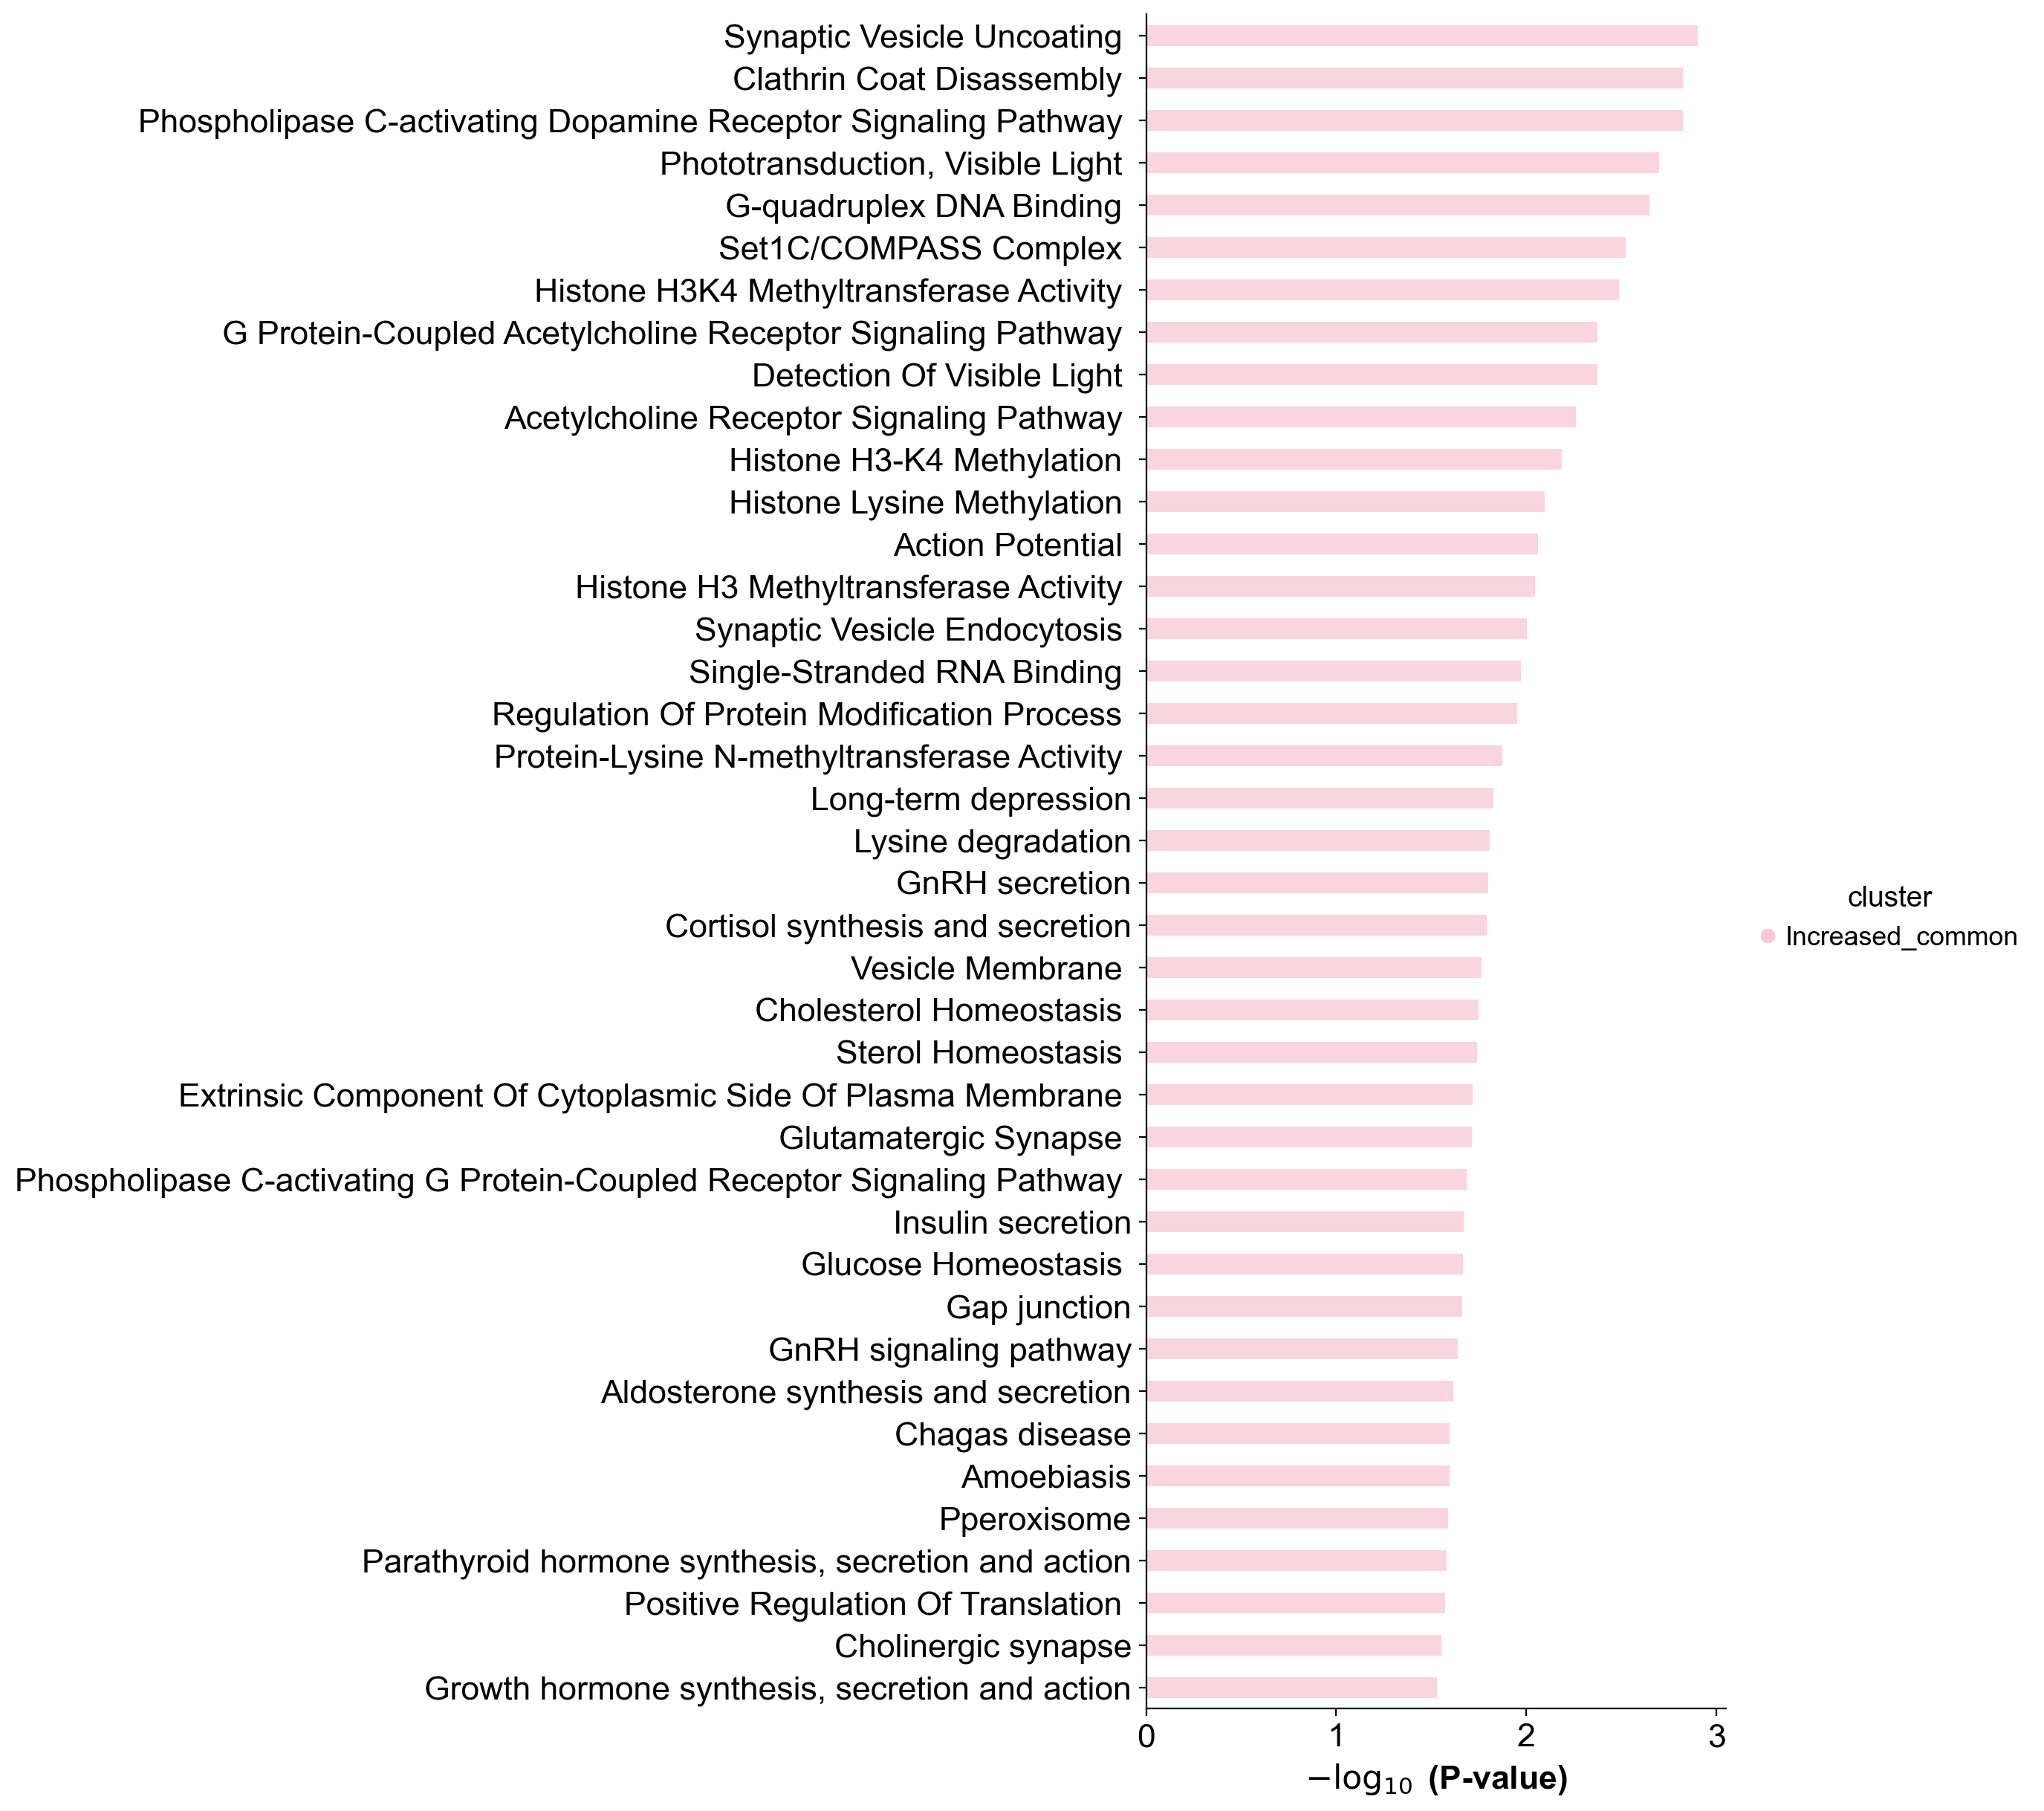

In [40]:
ax = barplot(enr_res_onco,
             #column="Adjusted P-value",
             column="P-value",
             group ='cluster',
             #group='Gene_set', # set group, so you could do a multi-sample/library comparsion
             size=0.2,
             top_term=40,
             #figsize=(10,6*len(enr.results[enr.results["P-value"] <= 0.05])/50),
             figsize=(5,15),
             color=bright_morandi_colors
             #color=['#ffc0cb',"#bebebe",'#00ffff',][::-1] # set colors for group
             #color = {'KEGG_2021_Human': 'salmon', 'MSigDB_Hallmark_2020':'darkblue'}
             )
plt.grid(False)
plt.savefig('./fig_cpr_rbg_stat_2/07.tracing/02.cluster_nx/increased_common/f04-onco-gene-pathway.pdf', bbox_inches='tight')

In [15]:
## genebody gene

In [41]:
## genebody gene
gsea_path = os.getcwd()+'./fig_cpr_rbg_stat_2/07.tracing/02.cluster_nx/increased_common/bodygene-pathway/'
if not os.path.exists(gsea_path): os.makedirs(gsea_path, exist_ok=True)
enrich_list = []
for sample in df_merge_body["group"].unique():
    print(sample)
    gene_list = df_merge_body[df_merge_body["group"]==sample]["genebody_region_gene_nor"].to_list()[0]
    enr_res_temp = gp_enrichr(gene_list=gene_list,sample=sample,path=gsea_path)
    print("done.")
    enrich_list.append(enr_res_temp)
    pass

Increased_common
done.


In [45]:
enr_res_body = pd.concat(enrich_list)
enr_res_body["cluster"] = pd.Categorical(enr_res_body["cluster"],
                                      categories=list(enr_res_body["cluster"].unique())[::-1],
                                      ordered=True)
enr_res_body.to_csv('./fig_cpr_rbg_stat_2/07.tracing/02.cluster_nx/increased_common/f05-body-gene-pathway.xls', sep='\t', index=True)

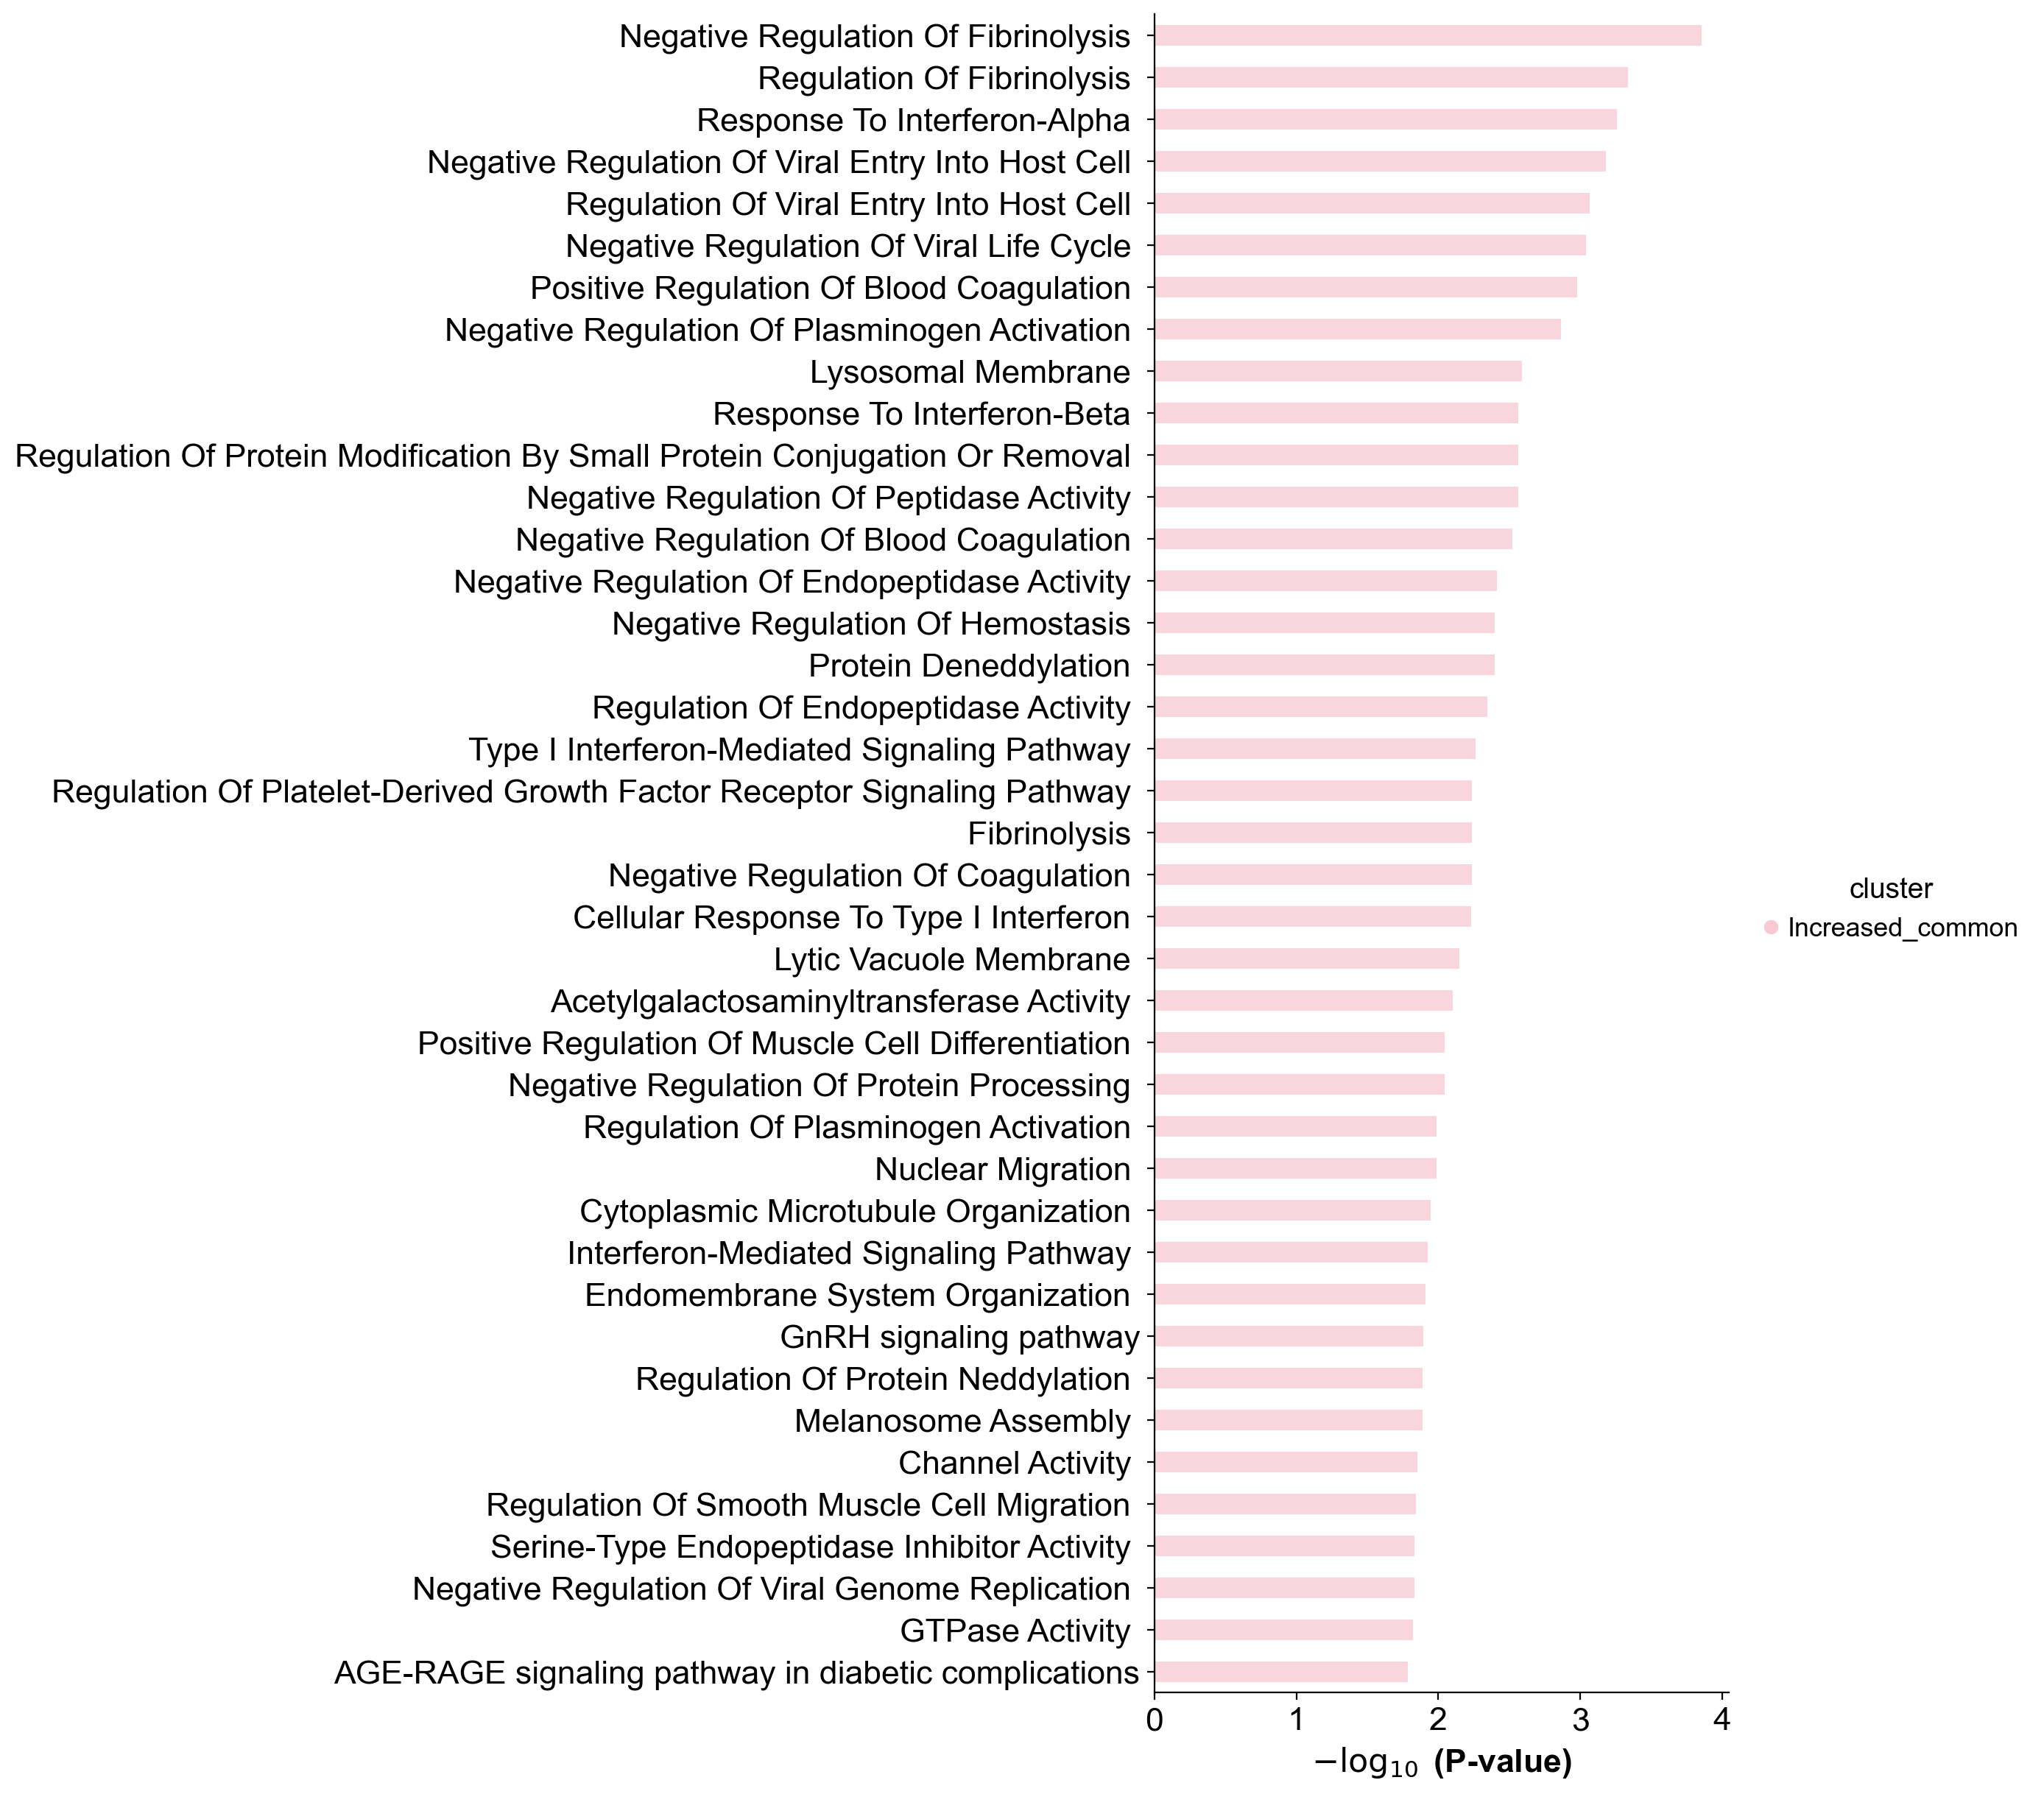

In [46]:
ax = barplot(enr_res_body,
             #column="Adjusted P-value",
             column="P-value",
             group ='cluster',
             #group='Gene_set', # set group, so you could do a multi-sample/library comparsion
             size=0.2,
             top_term=40,
             #figsize=(10,6*len(enr.results[enr.results["P-value"] <= 0.05])/50),
             figsize=(5,15),
             color=bright_morandi_colors
             #color=['#ffc0cb',"#bebebe",'#00ffff',][::-1] # set colors for group
             #color = {'KEGG_2021_Human': 'salmon', 'MSigDB_Hallmark_2020':'darkblue'}
             )
plt.grid(False)
plt.savefig('./fig_cpr_rbg_stat_2/07.tracing/02.cluster_nx/increased_common/f05-onco-gene-pathway.pdf', bbox_inches='tight')

In [47]:
### merge onco gene + body gene

In [48]:
### merge onco + body
enr_res_onco
enr_res_body
df_combined = pd.concat([enr_res_onco, enr_res_body])
df_combined

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes,Term_raw,cluster
24,GO_Biological_Process_2023,Synaptic Vesicle Uncoating,1/5,0.001249,0.018986,0,0,1249.437500,8352.531058,SH3GL1,Synaptic Vesicle Uncoating (GO:0016191),Increased_common
26,GO_Biological_Process_2023,Clathrin Coat Disassembly,1/6,0.001499,0.018986,0,0,999.500000,6499.559020,SH3GL1,Clathrin Coat Disassembly (GO:0072318),Increased_common
25,GO_Biological_Process_2023,Phospholipase C-activating Dopamine Receptor S...,1/6,0.001499,0.018986,0,0,999.500000,6499.559020,GNA11,Phospholipase C-activating Dopamine Receptor S...,Increased_common
27,GO_Biological_Process_2023,"Phototransduction, Visible Light",1/8,0.001999,0.018986,0,0,713.857143,4436.855318,GNA11,"Phototransduction, Visible Light (GO:0007603)",Increased_common
62,GO_Molecular_Function_2023,G-quadruplex DNA Binding,1/9,0.002248,0.024345,0,0,624.593750,3808.549663,CNBP,G-quadruplex DNA Binding (GO:0051880),Increased_common
...,...,...,...,...,...,...,...,...,...,...,...,...
1173,GO_Molecular_Function_2023,Cis-Regulatory Region Sequence-Specific DNA Bi...,3/1098,0.998725,0.999574,0,0,0.268393,0.000342,EGR1;GMEB2;SOX18,Cis-Regulatory Region Sequence-Specific DNA Bi...,Increased_common
1174,GO_Molecular_Function_2023,RNA Polymerase II Cis-Regulatory Region Sequen...,3/1122,0.998962,0.999574,0,0,0.262299,0.000272,EGR1;GMEB2;SOX18,RNA Polymerase II Cis-Regulatory Region Sequen...,Increased_common
1295,GO_Cellular_Component_2023,Nucleolus,1/771,0.999528,0.999569,0,0,0.128094,0.000060,SPC24,Nucleolus (GO:0005730),Increased_common
1296,GO_Cellular_Component_2023,Nuclear Lumen,1/780,0.999569,0.999569,0,0,0.126554,0.000055,SPC24,Nuclear Lumen (GO:0031981),Increased_common


In [49]:
enr_res_merge = df_combined.copy()
enr_res_merge["cluster"] = pd.Categorical(enr_res_merge["cluster"],
                                      categories=list(enr_res_merge["cluster"].unique())[::-1],
                                      ordered=True)
enr_res_merge.to_csv('./fig_cpr_rbg_stat_2/07.tracing/02.cluster_nx/increased_common/f06-merge-gene-pathway.xls', sep='\t', index=True)

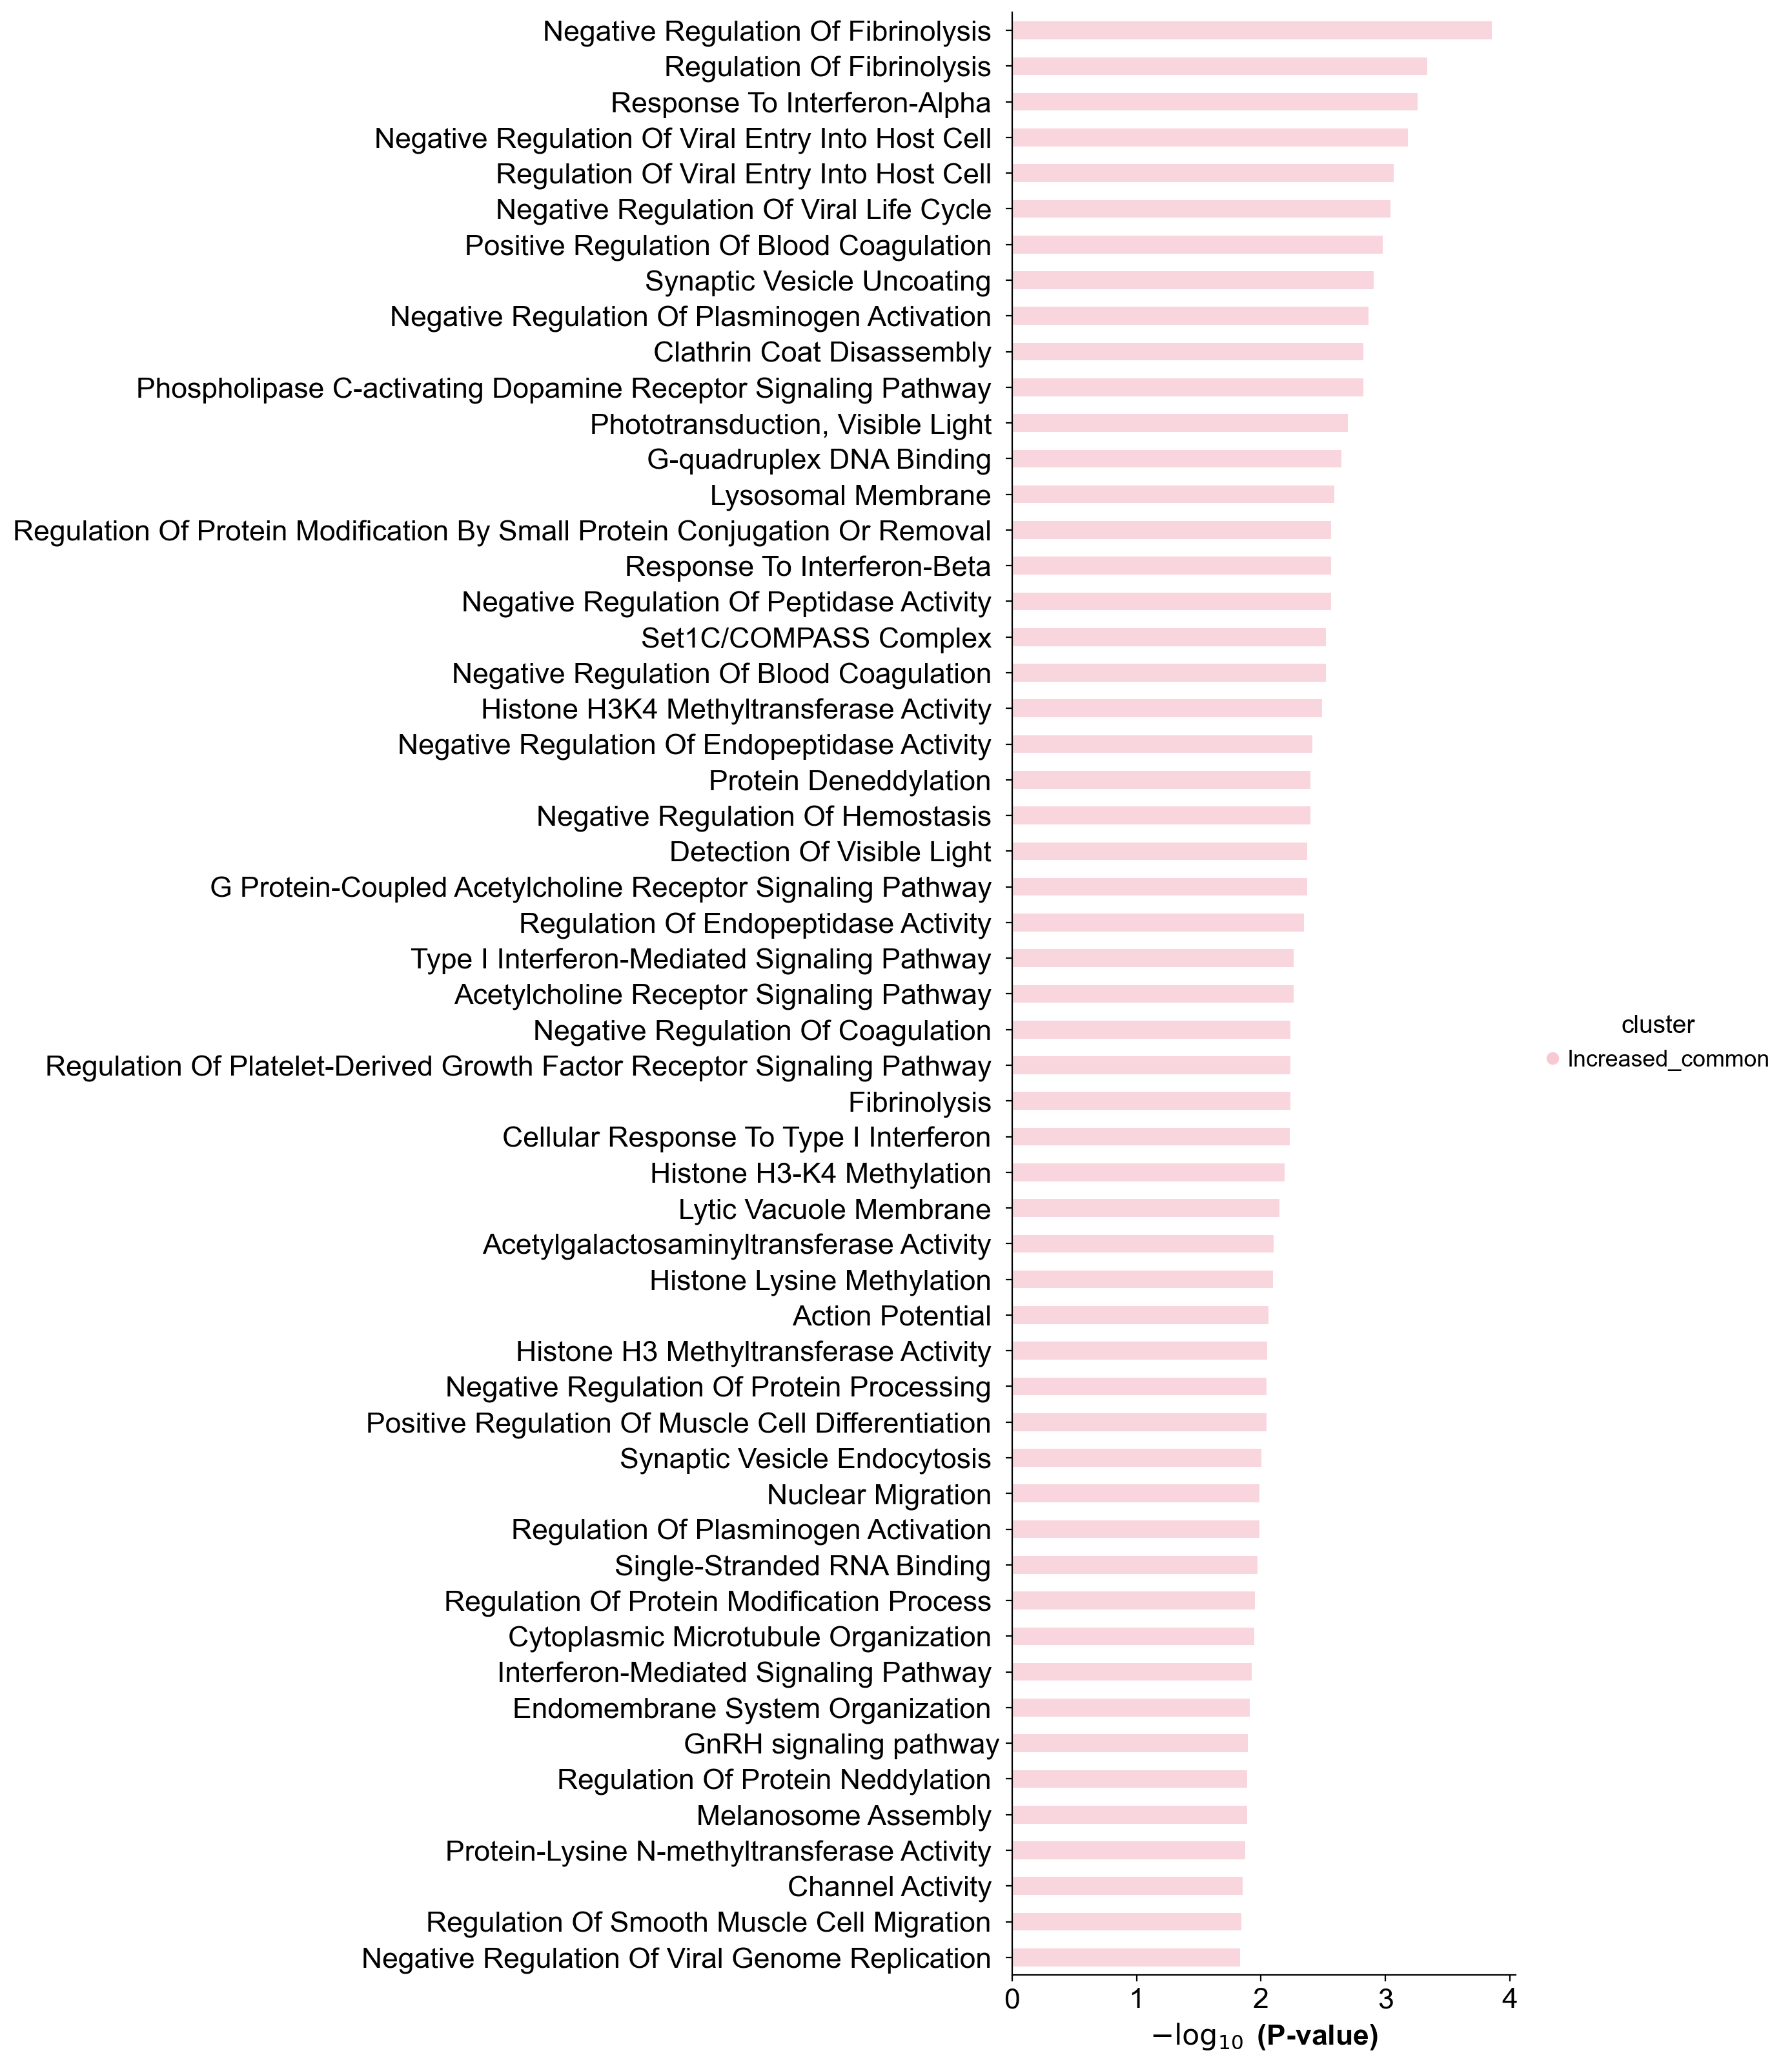

In [53]:
ax = barplot(enr_res_merge,
             #column="Adjusted P-value",
             column="P-value",
             group ='cluster',
             #group='Gene_set', # set group, so you could do a multi-sample/library comparsion
             size=0.2,
             top_term=55,
             #figsize=(10,6*len(enr.results[enr.results["P-value"] <= 0.05])/50),
             figsize=(5,20),
             color=bright_morandi_colors
             #color=['#ffc0cb',"#bebebe",'#00ffff',][::-1] # set colors for group
             #color = {'KEGG_2021_Human': 'salmon', 'MSigDB_Hallmark_2020':'darkblue'}
             )
plt.grid(False)
plt.savefig('./fig_cpr_rbg_stat_2/07.tracing/02.cluster_nx/increased_common/f06-merge-gene-pathway.pdf', bbox_inches='tight')